In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Paths — relative so anyone can run this
DATA_RAW = Path('../data/raw')
FIGURES  = Path('../outputs/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

# Fix random seed
import random
random.seed(42)
np.random.seed(42)


print("All imports successful")
# Load the main company table
obj = pd.read_csv(DATA_RAW / 'objects.csv', low_memory=False)

print("Shape:", obj.shape)
print("\nColumn names:")
print(obj.columns.tolist())
print("Exit status distribution:")
print(obj['status'].value_counts())
print("\nTotal:", len(obj))

All imports successful
Shape: (462651, 40)

Column names:
['id', 'entity_type', 'entity_id', 'parent_id', 'name', 'normalized_name', 'permalink', 'category_code', 'status', 'founded_at', 'closed_at', 'domain', 'homepage_url', 'twitter_username', 'logo_url', 'logo_width', 'logo_height', 'short_description', 'description', 'overview', 'tag_list', 'country_code', 'state_code', 'city', 'region', 'first_investment_at', 'last_investment_at', 'investment_rounds', 'invested_companies', 'first_funding_at', 'last_funding_at', 'funding_rounds', 'funding_total_usd', 'first_milestone_at', 'last_milestone_at', 'milestones', 'relationships', 'created_by', 'created_at', 'updated_at']
Exit status distribution:
status
operating      443663
acquired         9394
live             4349
closed           2773
ipo              1134
beta              780
development       226
private           219
alpha             113
Name: count, dtype: int64

Total: 462651


In [ ]:
print(obj['founded_at'].max())
print(obj['updated_at'].max())
print(obj['founded_year'].max())
# Understand the full date range of the dataset
funded = obj[obj['funding_rounds'] > 0].copy()
funded['founded_year'] = pd.to_datetime(funded['founded_at'], errors='coerce').dt.year

print("=== Full dataset date range ===")
print(f"Earliest founding year: {funded['founded_year'].min()}")
print(f"Latest founding year:   {funded['founded_year'].max()}")
print(f"Total funded companies: {len(funded)}")

print("\n=== Companies founded per decade ===")
bins = [1900, 1970, 1980, 1990, 1995, 2000, 2005, 2010, 2015]
labels = ['pre-1970','1970s','1980s','1990-94','1995-99','2000-04','2005-09','2010-14']
funded['decade'] = pd.cut(funded['founded_year'], bins=bins, labels=labels)
print(funded['decade'].value_counts().sort_index())

print("\n=== Status distribution by decade ===")
print(funded.groupby('decade')['status'].value_counts().unstack().fillna(0).astype(int))
cohort = funded[(funded['founded_year'] >= 2000) & 
                (funded['founded_year'] <= 2009)].copy()

print("Cohort size:", len(cohort))
print("\nStatus distribution:")
print(cohort['status'].value_counts())
print("\nExit rate:", 
      round((cohort['status'].isin(['acquired','ipo']).sum() / len(cohort))*100, 1), "%") 



2014-10-01
2013-12-12 14:29:40
2014.0
=== Full dataset date range ===
Earliest founding year: 1903.0
Latest founding year:   2014.0
Total funded companies: 31707

=== Companies founded per decade ===
decade
pre-1970       95
1970s         113
1980s         368
1990-94       470
1995-99      2061
2000-04      4051
2005-09     10304
2010-14      7005
Name: count, dtype: int64

=== Status distribution by decade ===
status    acquired  closed  ipo  operating
decade                                    
pre-1970         4       3   12         76
1970s            5       6    9         93
1980s           43      12   42        271
1990-94         61      11   37        361
1995-99        386      86   80       1509
2000-04        609     256   88       3098
2005-09        808     973   44       8479
2010-14        121     228    8       6648


In [13]:
print("=== What is in objects.csv? ===")
print(obj['entity_type'].value_counts())

print("\n=== Companies only ===")
companies = obj[obj['entity_type'] == 'Company']
print("Total companies:", len(companies))

print("\n=== Company funding status ===")
print("Has funding rounds > 0:", (companies['funding_rounds'] > 0).sum())
print("Has funding rounds = 0:", (companies['funding_rounds'] == 0).sum())
print("Funding rounds is NaN:", companies['funding_rounds'].isna().sum())

print("\n=== Status of ALL companies ===")
print(companies['status'].value_counts())

print("\n=== Status of UNFUNDED companies ===")
unfunded = companies[companies['funding_rounds'] == 0]
print(unfunded['status'].value_counts())



=== What is in objects.csv? ===
entity_type
Person          226708
Company         196553
Product          27738
FinancialOrg     11652
Name: count, dtype: int64

=== Companies only ===
Total companies: 196553

=== Company funding status ===
Has funding rounds > 0: 31707
Has funding rounds = 0: 164846
Funding rounds is NaN: 0

=== Status of ALL companies ===
status
operating    183441
acquired       9394
closed         2584
ipo            1134
Name: count, dtype: int64

=== Status of UNFUNDED companies ===
status
operating    156906
acquired       6801
ipo             644
closed          495
Name: count, dtype: int64


In [14]:
companies = obj[obj['entity_type'] == 'Company'].copy()
funded_cos = companies[companies['funding_rounds'] > 0].copy()
funded_cos['founded_year'] = pd.to_datetime(
    funded_cos['founded_at'], errors='coerce').dt.year

for start, end in [(1995,2009), (1998,2009), (2000,2009), (2000,2010)]:
    cohort = funded_cos[
        (funded_cos['founded_year'] >= start) & 
        (funded_cos['founded_year'] <= end)
    ].copy()
    
    acquired = (cohort['status'] == 'acquired').sum()
    ipo      = (cohort['status'] == 'ipo').sum()
    closed   = (cohort['status'] == 'closed').sum()
    operating= (cohort['status'] == 'operating').sum()
    total    = len(cohort)
    exits    = acquired + ipo
    
    print(f"\n{'='*40}")
    print(f"Cohort {start}-{end}")
    print(f"Total:     {total:,}")
    print(f"Exit (pos): {exits:,} ({round(exits/total*100,1)}%)")
    print(f"No exit:   {total-exits:,} ({round((total-exits)/total*100,1)}%)")
    print(f"  acquired: {acquired:,}")
    print(f"  ipo:      {ipo:,}")
    print(f"  closed:   {closed:,}")
    print(f"  operating:{operating:,}")


Cohort 1995-2009
Total:     13,768
Exit (pos): 1,918 (13.9%)
No exit:   11,850 (86.1%)
  acquired: 1,696
  ipo:      222
  closed:   1,101
  operating:10,749

Cohort 1998-2009
Total:     13,162
Exit (pos): 1,781 (13.5%)
No exit:   11,381 (86.5%)
  acquired: 1,594
  ipo:      187
  closed:   1,084
  operating:10,297

Cohort 2000-2009
Total:     12,261
Exit (pos): 1,562 (12.7%)
No exit:   10,699 (87.3%)
  acquired: 1,420
  ipo:      142
  closed:   1,046
  operating:9,653

Cohort 2000-2010
Total:     15,056
Exit (pos): 1,700 (11.3%)
No exit:   13,356 (88.7%)
  acquired: 1,553
  ipo:      147
  closed:   1,263
  operating:12,093


In [15]:
companies = obj[obj['entity_type'] == 'Company'].copy()
companies['founded_year'] = pd.to_datetime(
    companies['founded_at'], errors='coerce').dt.year

unfunded = companies[companies['funding_rounds'] == 0].copy()
unfunded_cohort = unfunded[
    (unfunded['founded_year'] >= 1995) & 
    (unfunded['founded_year'] <= 2009)
]

print("=== Unfunded companies in our cohort ===")
print(f"Total unfunded: {len(unfunded_cohort):,}")
print(f"\nStatus:")
print(unfunded_cohort['status'].value_counts())

exits = unfunded_cohort['status'].isin(['acquired','ipo']).sum()
print(f"\nExits among unfunded: {exits:,}")
print(f"Exit rate: {exits/len(unfunded_cohort)*100:.1f}%")

=== Unfunded companies in our cohort ===
Total unfunded: 33,049

Status:
status
operating    30875
acquired      1823
closed         245
ipo            106
Name: count, dtype: int64

Exits among unfunded: 1,929
Exit rate: 5.8%


In [16]:
# FINAL COHORT DECISION — 1995 to 2009
companies = obj[obj['entity_type'] == 'Company'].copy()
funded_cos = companies[companies['funding_rounds'] > 0].copy()
funded_cos['founded_year'] = pd.to_datetime(
    funded_cos['founded_at'], errors='coerce').dt.year

cohort = funded_cos[
    (funded_cos['founded_year'] >= 1995) & 
    (funded_cos['founded_year'] <= 2009)
].copy()

# CREATE BINARY TARGET LABEL
# 1 = successful exit (acquired or ipo)
# 0 = no successful exit (operating or closed)
cohort['label'] = cohort['status'].apply(
    lambda x: 1 if x in ['acquired', 'ipo'] else 0
)

# SANITY CHECK
print("=== FINAL COHORT ===")
print(f"Total companies: {len(cohort):,}")
print(f"\nLabel distribution:")
print(cohort['label'].value_counts())
print(f"\nClass balance:")
print(f"Exit (1):    {cohort['label'].sum():,} ({cohort['label'].mean()*100:.1f}%)")
print(f"No exit (0): {(cohort['label']==0).sum():,} ({(1-cohort['label'].mean())*100:.1f}%)")
print(f"\nCohort saved. Moving to feature engineering.")

=== FINAL COHORT ===
Total companies: 13,768

Label distribution:
label
0    11850
1     1918
Name: count, dtype: int64

Class balance:
Exit (1):    1,918 (13.9%)
No exit (0): 11,850 (86.1%)

Cohort saved. Moving to feature engineering.


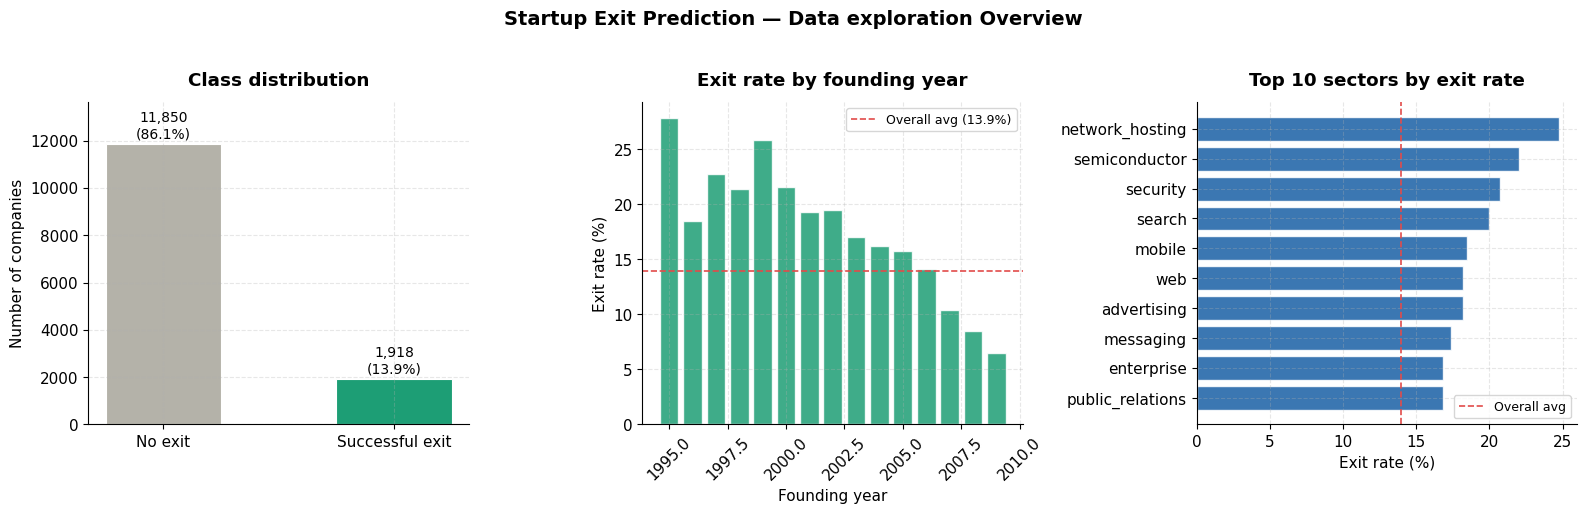

Saved to outputs/figures/eda_overview.png


In [20]:
# figure graph
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

# Colour palette — two colours only
COL_EXIT   = '#1D9E75'  # green for exits
COL_NOEXIT = '#B4B2A9'  # grey for no exit
COL_BLUE   = '#185FA5'  # blue for sector chart

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Startup Exit Prediction — Data exploration Overview',
             fontsize=14, fontweight='bold', y=1.02)

# ── Figure 1: Class distribution ──────────────────────────────
labels_map = {0: 'No exit', 1: 'Successful exit'}
counts = cohort['label'].value_counts().sort_index()
bars = axes[0].bar(
    [labels_map[i] for i in counts.index],
    counts.values,
    color=[COL_NOEXIT, COL_EXIT],
    width=0.5, edgecolor='white', linewidth=0.8
)
axes[0].set_title('Class distribution', fontweight='bold', pad=12)
axes[0].set_ylabel('Number of companies')
axes[0].set_ylim(0, counts.max() * 1.15)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 150,
                 f'{val:,}\n({val/len(cohort)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)

# ── Figure 2: Exit rate by founding year ──────────────────────
year_data = cohort.groupby('founded_year').agg(
    total=('label', 'count'),
    exits=('label', 'sum')
).reset_index()
year_data['exit_rate'] = year_data['exits'] / year_data['total'] * 100

axes[1].bar(year_data['founded_year'], year_data['exit_rate'],
            color=COL_EXIT, alpha=0.85, edgecolor='white')
axes[1].axhline(cohort['label'].mean() * 100,
                color='#E24B4A', linestyle='--',
                linewidth=1.2, label=f"Overall avg ({cohort['label'].mean()*100:.1f}%)")
axes[1].set_title('Exit rate by founding year', fontweight='bold', pad=12)
axes[1].set_ylabel('Exit rate (%)')
axes[1].set_xlabel('Founding year')
axes[1].legend(fontsize=9)
axes[1].tick_params(axis='x', rotation=45)

# ── Figure 3: Top 10 sectors by exit rate ─────────────────────
sector_stats = cohort.groupby('category_code').agg(
    total=('label', 'count'),
    exits=('label', 'sum')
).reset_index()
sector_stats = sector_stats[sector_stats['total'] >= 30]  # min sample
sector_stats['exit_rate'] = sector_stats['exits'] / sector_stats['total'] * 100
top10 = sector_stats.nlargest(10, 'exit_rate')

axes[2].barh(top10['category_code'], top10['exit_rate'],
             color=COL_BLUE, alpha=0.85, edgecolor='white')
axes[2].axvline(cohort['label'].mean() * 100,
                color='#E24B4A', linestyle='--',
                linewidth=1.2, label='Overall avg')
axes[2].set_title('Top 10 sectors by exit rate', fontweight='bold', pad=12)
axes[2].set_xlabel('Exit rate (%)')
axes[2].invert_yaxis()
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / 'eda_overview.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Saved to outputs/figures/eda_overview.png")

In [21]:
# Save cohort for notebook 2
DATA_PROCESSED = Path('../data/processed')
DATA_PROCESSED.mkdir(exist_ok=True)
cohort.to_csv(DATA_PROCESSED / 'cohort.csv', index=False)
print(f"Cohort saved: {len(cohort):,} rows, {cohort.shape[1]} columns")
print(f"Exits: {cohort['label'].sum():,} | No exit: {(cohort['label']==0).sum():,}")
print("Notebook 1 complete.")

Cohort saved: 13,768 rows, 42 columns
Exits: 1,918 | No exit: 11,850
Notebook 1 complete.
